# 🌡️ Analisis & Prediksi Cuaca IoT — Pengamatan 2
**Mata Kuliah:** Kecerdasan Buatan  
**Dataset:** `sensor_data_2.csv` — sensor IoT (suhu, kelembapan, cahaya) interval ~5 menit  
**Periode:** 13 – 18 April 2026 (WIB, GMT+7)  

---

## 🗺️ Alur Analisis
1. Import Library
2. Load & Inspect Data
3. Preprocessing — konversi timezone GMT → WIB, parsing, sorting
4. Audit Kualitas Data — gap jaringan, interval tidak konsisten
5. Handling Missing Values — reindex + interpolasi
6. Feature Engineering
7. EDA — Univariat · Bivariat · Multivariat · Time-Series Story
8. Deteksi Outlier
9. Prediksi Suhu — Regresi Linear & ARIMA Walk-Forward
10. Kesimpulan & Rekomendasi

---
> **Catatan Perbedaan Data Ini vs Pengamatan 1:**  
> - Timestamp dalam **GMT+0** → perlu konversi ke **WIB (GMT+7)**  
> - Gap besar ~925 menit (~15.4 jam) pada 13–14 April  
> - Interval pengiriman tidak tepat 5 menit (network jitter)  
> - Dataset **jauh lebih besar**: 1.256 record selama 5 hari  


## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print('Semua library berhasil di import')

Semua library berhasil di import


## 2. Load & Inspect Data

Data mentah dari pipeline backend. Perhatikan kolom `created_at` — formatnya menyertakan offset `+00` (UTC), bukan WIB.

In [2]:
df_raw = pd.read_csv('sensor_data_2.csv')

print(f'Shape: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom')
print()
print('=== 5 BARIS PERTAMA ===')
display(df_raw.head())
print()
print('=== INFO KOLOM ===')
df_raw.info()
print()
print('=== SAMPEL NILAI ===')
for col in df_raw.columns:
  print(f'  {col:15s}: {str(df_raw[col].iloc[0])!r}  (dtype: {df_raw[col].dtype})')

Shape: 1256 baris x 6 kolom

=== 5 BARIS PERTAMA ===


,id,created_at,suhu,kelembapan,cahaya,kondisi
0,18,2026-04-13 02:52:00.210695+00,29.8,71.5,711,TERANG
1,19,2026-04-13 02:57:00.190764+00,29.8,70.9,400,TERANG
2,20,2026-04-13 03:03:00.467898+00,30.0,68.5,389,TERANG
3,21,2026-04-13 03:08:00.503225+00,29.8,69.9,260,TERANG
4,22,2026-04-13 03:13:00.613372+00,30.4,68.1,247,TERANG



=== INFO KOLOM ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          1256 non-null   int64  
 1   created_at  1256 non-null   object 
 2   suhu        1256 non-null   float64
 3   kelembapan  1256 non-null   float64
 4   cahaya      1256 non-null   int64  
 5   kondisi     1256 non-null   object 
dtypes: float64(2), int64(2), object(2)
memory usage: 59.0+ KB

=== SAMPEL NILAI ===
  id             : '18'  (dtype: int64)
  created_at     : '2026-04-13 02:52:00.210695+00'  (dtype: object)
  suhu           : '29.8'  (dtype: float64)
  kelembapan     : '71.5'  (dtype: float64)
  cahaya         : '711'  (dtype: int64)
  kondisi        : 'TERANG'  (dtype: object)


## 3. Preprocessing

### Mengapa Perlu Konversi Timezone?

Data dikirim dengan timestamp **UTC (GMT+0)** dari backend Supabase. Sensor berada di **Semarang, Indonesia (WIB = GMT+7)**. Tanpa konversi, pola harian akan bergeser 7 jam — puncak suhu siang akan tampak terjadi pukul 07:00 UTC, bukan 14:00 WIB yang sebenarnya.

**Solusi:** `tz_convert('Asia/Jakarta')` secara otomatis menangani konversi dengan benar.

In [3]:
df = df_raw.copy()

# parse timestamp dan konversi UTC -> WIB (+7)
df['timestamp'] = pd.to_datetime(df['created_at'], utc=True)
df['timestamp'] = df['timestamp'].dt.tz_convert('Asia/Jakarta')

# urutkan dan set index
df = df.sort_values('timestamp').reset_index(drop=True)
df = df.set_index('timestamp')

# convert to numeric
df['suhu']       = pd.to_numeric(df['suhu'],       errors='coerce')
df['kelembapan'] = pd.to_numeric(df['kelembapan'], errors='coerce')
df['cahaya']     = pd.to_numeric(df['cahaya'],     errors='coerce')

print('Preprocessing selesai!')
print(f'Rentang waktu (WIB): {df.index.min().strftime("%d %b %Y %H:%M")} -> {df.index.max().strftime("%d %b %Y %H:%M")}')
print(f'Durasi total        : {df.index.max() - df.index.min()}')
print()
display(df.head(3))

Preprocessing selesai!
Rentang waktu (WIB): 13 Apr 2026 09:52 -> 18 Apr 2026 19:46
Durasi total        : 5 days 09:54:01.780541



,id,created_at,suhu,kelembapan,cahaya,kondisi
timestamp,,,,,,
2026-04-13 09:52:00.210695+07:00,18,2026-04-13 02:52:00.210695+00,29.8,71.5,711,TERANG
2026-04-13 09:57:00.190764+07:00,19,2026-04-13 02:57:00.190764+00,29.8,70.9,400,TERANG
2026-04-13 10:03:00.467898+07:00,20,2026-04-13 03:03:00.467898+00,30.0,68.5,389,TERANG


## 4. Audit Kualitas Data

Sebelum mengisi missing value, kita perlu memahami *seberapa parah* masalah data ini:

1. **Gap Besar** — periode panjang di mana sensor tidak mengirim data sama sekali (jaringan down total)  
2. **Jitter Interval** — pengiriman tidak tepat 5 menit karena latensi jaringan  

In [4]:
# hitung gap antar data
df_temp = df.reset_index()
df_temp['gap_menit'] = df_temp['timestamp'].diff().dt.total_seconds() / 60

# ringkasan distribusi interval
q = df_temp['gap_menit'].dropna()
print('=== DISTRIBUSI INTERVAL PENGIRIMAN ===')
print(f'  Median interval  : {q.median():.1f} menit')
print(f'  95th percentile  : {q.quantile(0.95):.1f} menit')
print(f'  Interval > 7 min : {(q>7).sum()} kejadian')
print(f'  Interval > 60 min: {(q>60).sum()} kejadian')

big_gaps = df_temp[df_temp['gap_menit'] > 10][['timestamp', 'gap_menit']].copy()
print(f'\n=== GAP > 10 MENIT: {len(big_gaps)} kejadian ===')
print(f'Total menit hilang: {big_gaps["gap_menit"].sum():.0f} menit ({big_gaps["gap_menit"].sum()/60:.1f} jam)')
print()
print('TOP 5 GAP TERBESAR:')
print(big_gaps.nlargest(5, 'gap_menit').to_string(index=False))

=== DISTRIBUSI INTERVAL PENGIRIMAN ===
  Median interval  : 5.0 menit
  95th percentile  : 10.1 menit
  Interval > 7 min : 82 kejadian
  Interval > 60 min: 1 kejadian

=== GAP > 10 MENIT: 81 kejadian ===
Total menit hilang: 1902 menit (31.7 jam)

TOP 5 GAP TERBESAR:
                       timestamp  gap_menit
2026-04-14 13:09:14.893051+07:00 925.737846
2026-04-16 18:55:07.375228+07:00  30.603702
2026-04-16 07:44:45.666848+07:00  22.538890
2026-04-17 10:05:35.682281+07:00  20.484372
2026-04-15 09:15:19.553029+07:00  20.228236


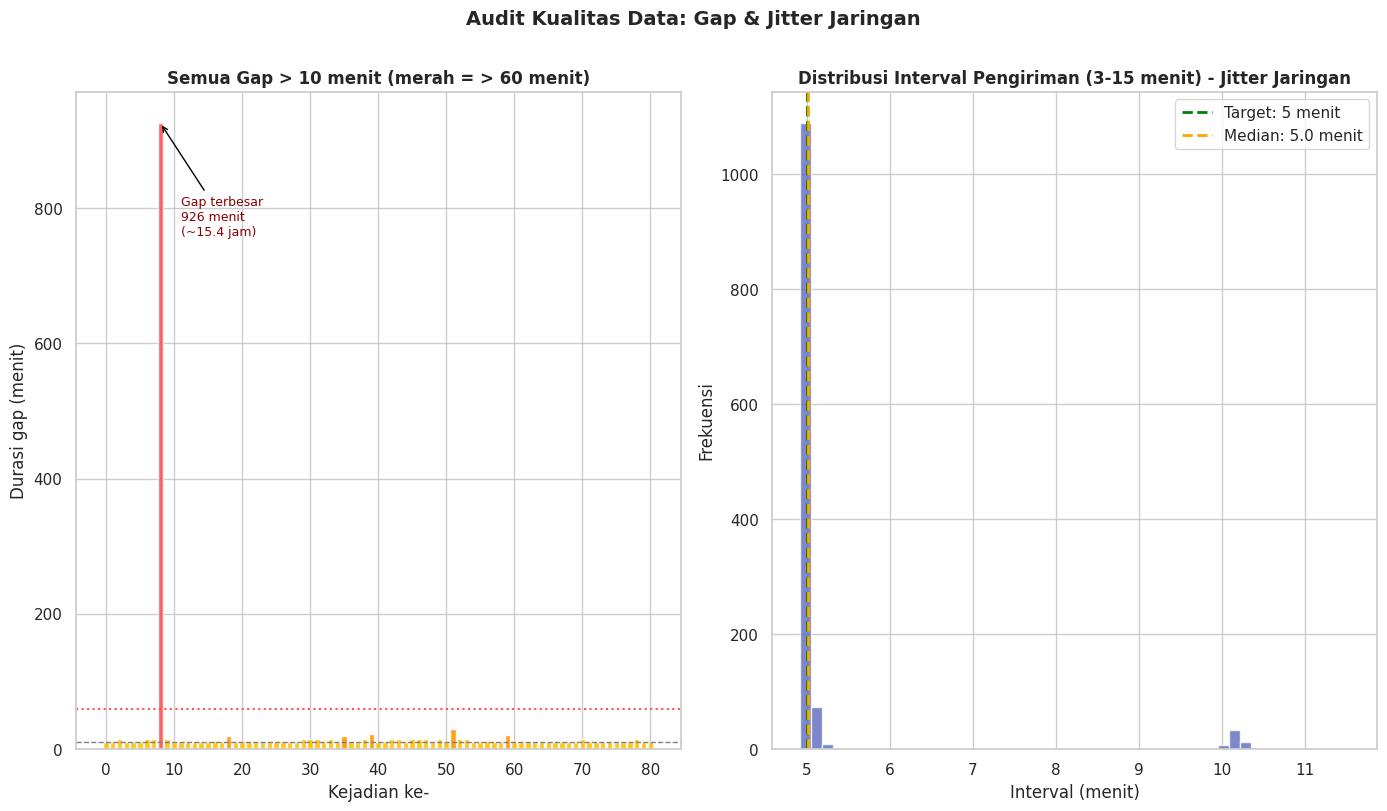


Insight:
  Sebagian besar data dikirim mendekati 5 menit (median: 5.0 min)
  1 gap kritis: ~925 menit (~15.4 jam) pada 13-14 April 2026
  Sisa 80 gap adalah jitter biasa (<35 menit)


In [5]:
# visualisasi gap (timeline dan distribusi interval)
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# plot 1: bar chart gap
ax1 = axes[0]
big_gaps_sorted = big_gaps.sort_values('timestamp')
col_bars = ['#FF5252' if g > 60 else '#FF9800' if g > 20 else '#FFC107'
            for g in big_gaps_sorted['gap_menit']]
ax1.bar(range(len(big_gaps_sorted)), big_gaps_sorted['gap_menit'].values,
        color=col_bars, edgecolor='white', alpha=0.9)
ax1.axhline(y=10, color='gray', linestyle='--', lw=1, label='Threshold 10 menit')
ax1.axhline(y=60, color='#FF5252', linestyle=':', lw=1.5, label='Threshold 1 jam')
ax1.set_xlabel('Kejadian ke-')
ax1.set_ylabel('Durasi gap (menit)')
ax1.set_title('Semua Gap > 10 menit (merah = > 60 menit)', fontweight='bold')

# anotasi gap terbesar
max_idx = big_gaps_sorted['gap_menit'].idxmax()
max_pos = list(big_gaps_sorted.index).index(max_idx)
max_val = big_gaps_sorted.loc[max_idx, 'gap_menit']
ax1.annotate(f"Gap terbesar\n{max_val:.0f} menit\n(~15.4 jam)",
             xy=(max_pos, max_val),
             xytext=(max_pos + 3, max_val * 0.82),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=9, color='darkred')

# plot 2: histogram interval
ax2 = axes[1]
interval_trim = q[(q >= 3) & (q <= 15)]
ax2.hist(interval_trim, bins=50, color='#5C6BC0', alpha=0.8, edgecolor='white')
ax2.axvline(x=5, color='green', linestyle='--', lw=2, label='Target: 5 menit')
ax2.axvline(x=q.median(), color='orange', linestyle='--', lw=2, label=f'Median: {q.median():.1f} menit')
ax2.set_xlabel('Interval (menit)')
ax2.set_ylabel('Frekuensi')
ax2.set_title('Distribusi Interval Pengiriman (3-15 menit) - Jitter Jaringan', fontweight='bold')
ax2.legend()

plt.suptitle('Audit Kualitas Data: Gap & Jitter Jaringan', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nInsight:')
print(f'  Sebagian besar data dikirim mendekati 5 menit (median: {q.median():.1f} min)')
print('  1 gap kritis: ~925 menit (~15.4 jam) pada 13-14 April 2026')
print(f'  Sisa {len(big_gaps)-1} gap adalah jitter biasa (<35 menit)')

## 5. Handling Missing Values

### Strategi Imputasi

| Variabel | Metode | Alasan |
|----------|--------|--------|
| Suhu & Kelembapan | **Interpolasi linear** | Perubahan gradual, aman untuk gap pendek–menengah |
| Cahaya | **Forward fill** | Cahaya bisa berubah tiba-tiba, ffill lebih konservatif |
| Kondisi (TERANG/GELAP) | **Forward fill** | Variabel kategorikal |

> **Catatan:** Gap ~15 jam di-*flag* dengan warna berbeda dalam visualisasi agar interpretasi tidak menyesatkan, data di area merah adalah interpolasi jarak jauh, bukan data real.

In [6]:
# reindex ke grid 5 menit penuh
start    = df.index.min().floor('5min')
end      = df.index.max().ceil('5min')
full_idx = pd.date_range(start=start, end=end, freq='5min', tz='Asia/Jakarta')

df_full  = df.reindex(full_idx, method='nearest', tolerance=pd.Timedelta('3min'))
df_full.index_name = 'timestamp'
df_full['is_original'] = ~df_full['suhu'].isna()

n_total   = len(df_full)
n_asli    = df_full['is_original'].sum()
n_missing = (~df_full['is_original']).sum()

print(f'Total timestep 5-menit : {n_total}')
print(f'Data asli              : {n_asli}  ({n_asli/n_total*100:.1f}%)')
print(f'Baris diimputasi       : {n_missing} ({n_missing/n_total*100:.1f}%)')

# catat lokasi gap terbesar untuk visualisasi
df_temp3 = df.reset_index()
df_temp3['gap'] = df_temp3['timestamp'].diff().dt.total_seconds() / 60
big_gap_times = df_temp3[df_temp3['gap'] > 60].copy()
big_gap_times['start'] = df_temp3.loc[big_gap_times.index - 1, 'timestamp'].values
big_gap_times = big_gap_times[['timestamp', 'gap', 'start']].rename(columns={'timestamp': 'end'})

# imputasi
df_full['suhu']       = df_full['suhu'].interpolate(method='linear')
df_full['kelembapan'] = df_full['kelembapan'].interpolate(method='linear')
df_full['cahaya']     = df_full['cahaya'].ffill()
df_full['kondisi']    = df_full['kondisi'].ffill()

print(f'\nImputasi selesai. missing tersisa: {df_full[["suhu", "kelembapan", "cahaya"]].isna().sum().sum()}')

Total timestep 5-menit : 1561
Data asli              : 1279  (81.9%)
Baris diimputasi       : 282 (18.1%)

Imputasi selesai. missing tersisa: 0


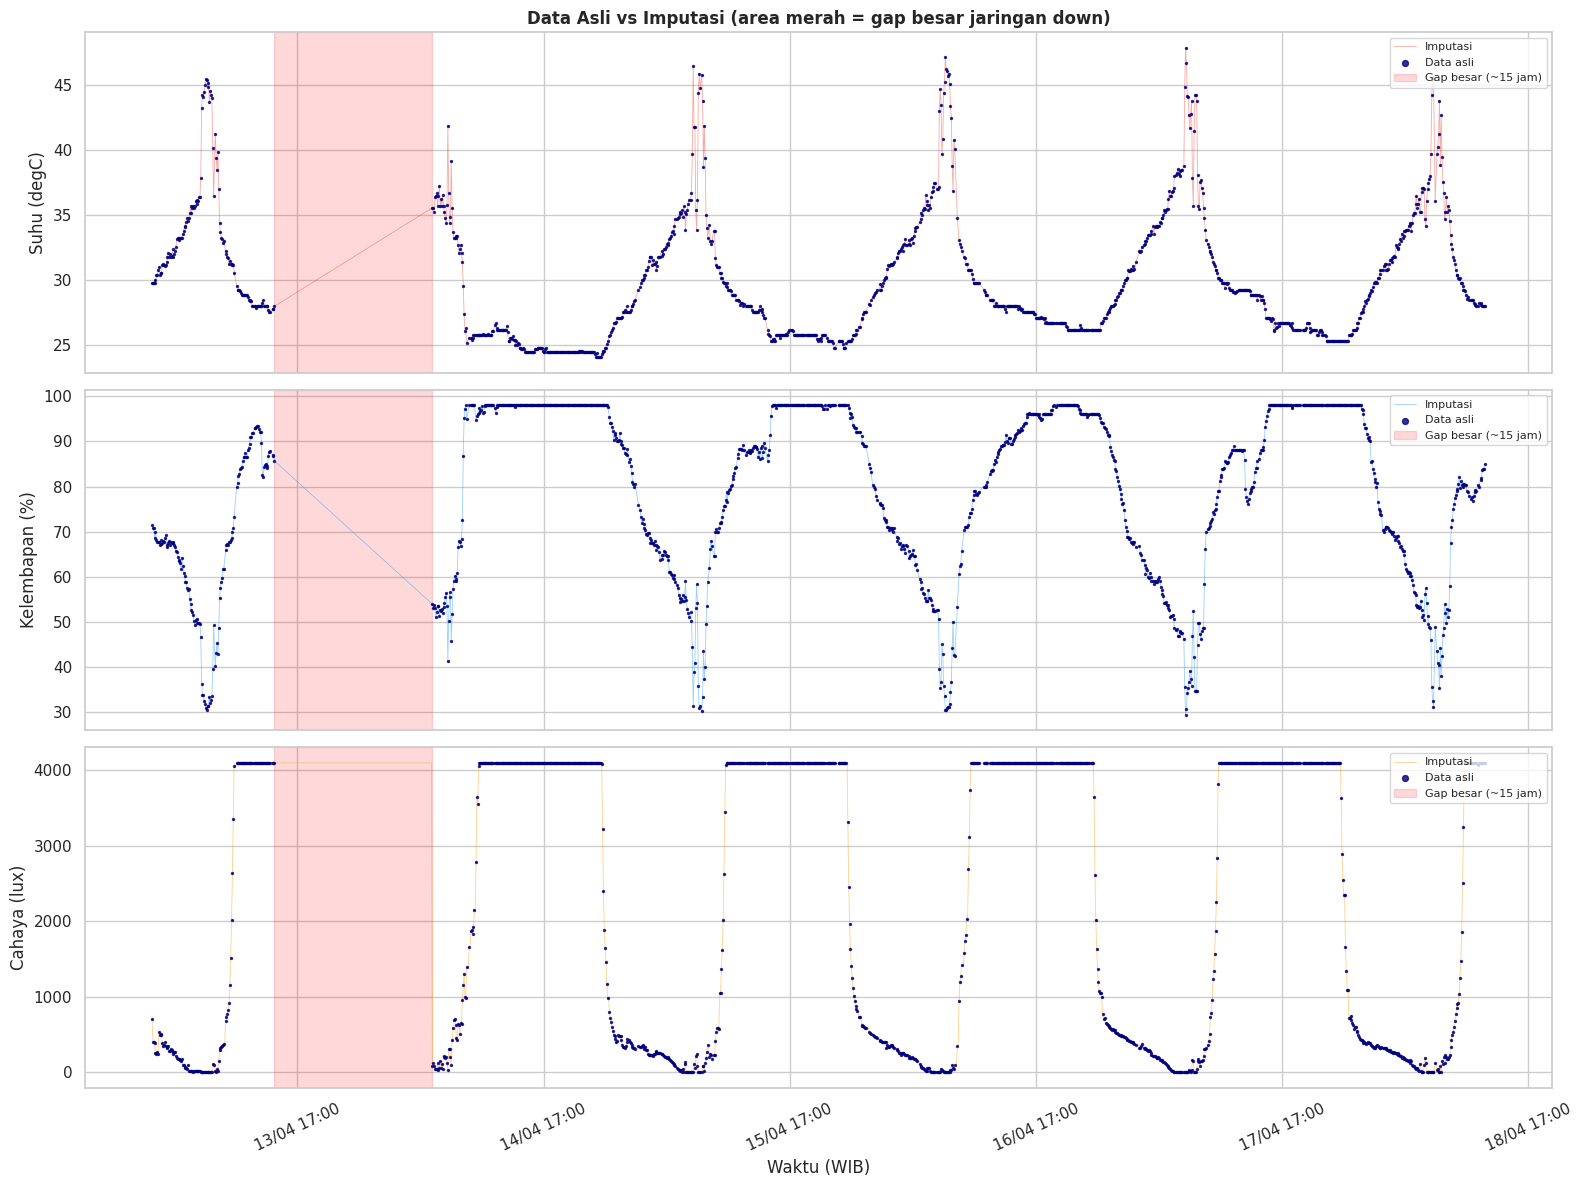

In [7]:
# visualisasi data asli vs imputas
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
cols_viz = [('suhu','#F44336','Suhu (degC)'),
            ('kelembapan','#2196F3','Kelembapan (%)'),
            ('cahaya','#FF9800','Cahaya (lux)')]

df_asli = df_full[df_full['is_original'] == True]

for ax, (col, color, label) in zip(axes, cols_viz):
  ax.plot(df_full.index, df_full[col], color=color, linewidth=0.6, alpha=0.45, label='Imputasi')
  ax.scatter(df_asli.index, df_asli[col], color='navy', s=2, zorder=4, alpha=0.8, label='Data asli')
  for idx2, row in big_gap_times.iterrows():
    ax.axvspan(row['start'], row['end'], alpha=0.15, color='red',
                   label='Gap besar (~15 jam)' if idx2 == big_gap_times.index[0] else '')
  ax.set_ylabel(label)
  ax.legend(loc='upper right', fontsize=8, markerscale=3)
  ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))

axes[0].set_title("Data Asli vs Imputasi (area merah = gap besar jaringan down)", fontweight='bold')
axes[-1].set_xlabel('Waktu (WIB)')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## 6. Feature Engineering

Mengekstrak informasi temporal dan membuat flag kontekstual.

In [9]:
df_feat = df_full.copy()

df_feat['jam']         = df_feat.index.hour
df_feat['menit']       = df_feat.index.minute
df_feat['hari_minggu'] = df_feat.index.dayofweek   # 0=Senin
df_feat['tanggal']     = df_feat.index.date
df_feat['hari_ke']     = (df_feat.index - df_feat.index.min()).total_seconds() / 86400

# fitur sikulus untuk model
df_feat['jam_sin'] = np.sin(2 * np.pi * df_feat['jam'] / 24)
df_feat['jam_cos'] = np.cos(2 * np.pi * df_feat['jam'] / 24)

# flag malam (21:00 - 05:59 WIB)
df_feat['is_malam'] = df_feat['jam'].apply(lambda h: 1 if h >= 21 or h < 6 else 0)

# Cahaya artifisial: malam tapi sensor masih tinggi (lampu)
THRESHOLD_CAHAYA = 2000
df_feat['cahaya_artifisial'] = (
    (df_feat['is_malam'] == 1) & (df_feat['cahaya'] > THRESHOLD_CAHAYA)
).astype(int)

# Cahaya saturasi: nilai 4095
df_feat['cahaya_saturasi'] = (df_feat['cahaya'] == 4095).astype(int)

n_art = df_feat['cahaya_artifisial'].sum()
n_sat = df_feat['cahaya_saturasi'].sum()
cols_sensor = ['suhu', 'kelembapan', 'cahaya']

print('Feature engineering selesai!')
print(f'  Cahaya artifisial malam: {n_art} timestep ({n_art*5/60:.1f} jam)')
print(f'  Cahaya saturasi (4095) : {n_sat} timestep ({n_sat/len(df_feat)*100:.1f}% data)')

Feature engineering selesai!
  Cahaya artifisial malam: 536 timestep (44.7 jam)
  Cahaya saturasi (4095) : 822 timestep (52.7% data)


## 7. EDA — Exploratory Data Analysis

### 7.1 Statistik Deskriptif

In [10]:
print('=== STATISTIK DESKRIPTIF ===')
display(df_feat[cols_sensor].describe().round(2))

print()
print('=== RENTANG SUHU & KELEMBAPAN PER HARI ===')
daily = df_feat.groupby('tanggal')[['suhu','kelembapan']].agg(['min','max','mean']).round(2)
display(daily)

=== STATISTIK DESKRIPTIF ===


,suhu,kelembapan,cahaya
count,1561.00,1561.0,1561.0
mean,30.23,77.9,2402.9
std,4.62,18.3,1862.5
min,24.10,29.4,0.0
25%,26.30,64.7,316.0
50%,29.27,80.4,4095.0
75%,33.00,96.9,4095.0
max,47.90,98.0,4095.0



=== RENTANG SUHU & KELEMBAPAN PER HARI ===


suhu              kelembapan             
             min   max   mean        min   max   mean
tanggal                                              
2026-04-13  27.6  45.5  32.13       30.5  93.5  69.47
2026-04-14  24.5  41.9  30.45       41.2  98.0  75.94
2026-04-15  24.1  46.5  28.95       30.1  98.0  81.19
2026-04-16  24.8  47.2  30.02       30.4  98.0  79.53
2026-04-17  26.1  47.9  30.54       29.4  98.0  78.39
2026-04-18  25.3  45.6  30.04       31.1  98.0  79.73

### 7.2 Analisis Univariat — Distribusi Tiap Variabel

Histogram + KDE menunjukkan sebaran nilai; apakah normal, miring kiri, atau bimodal.

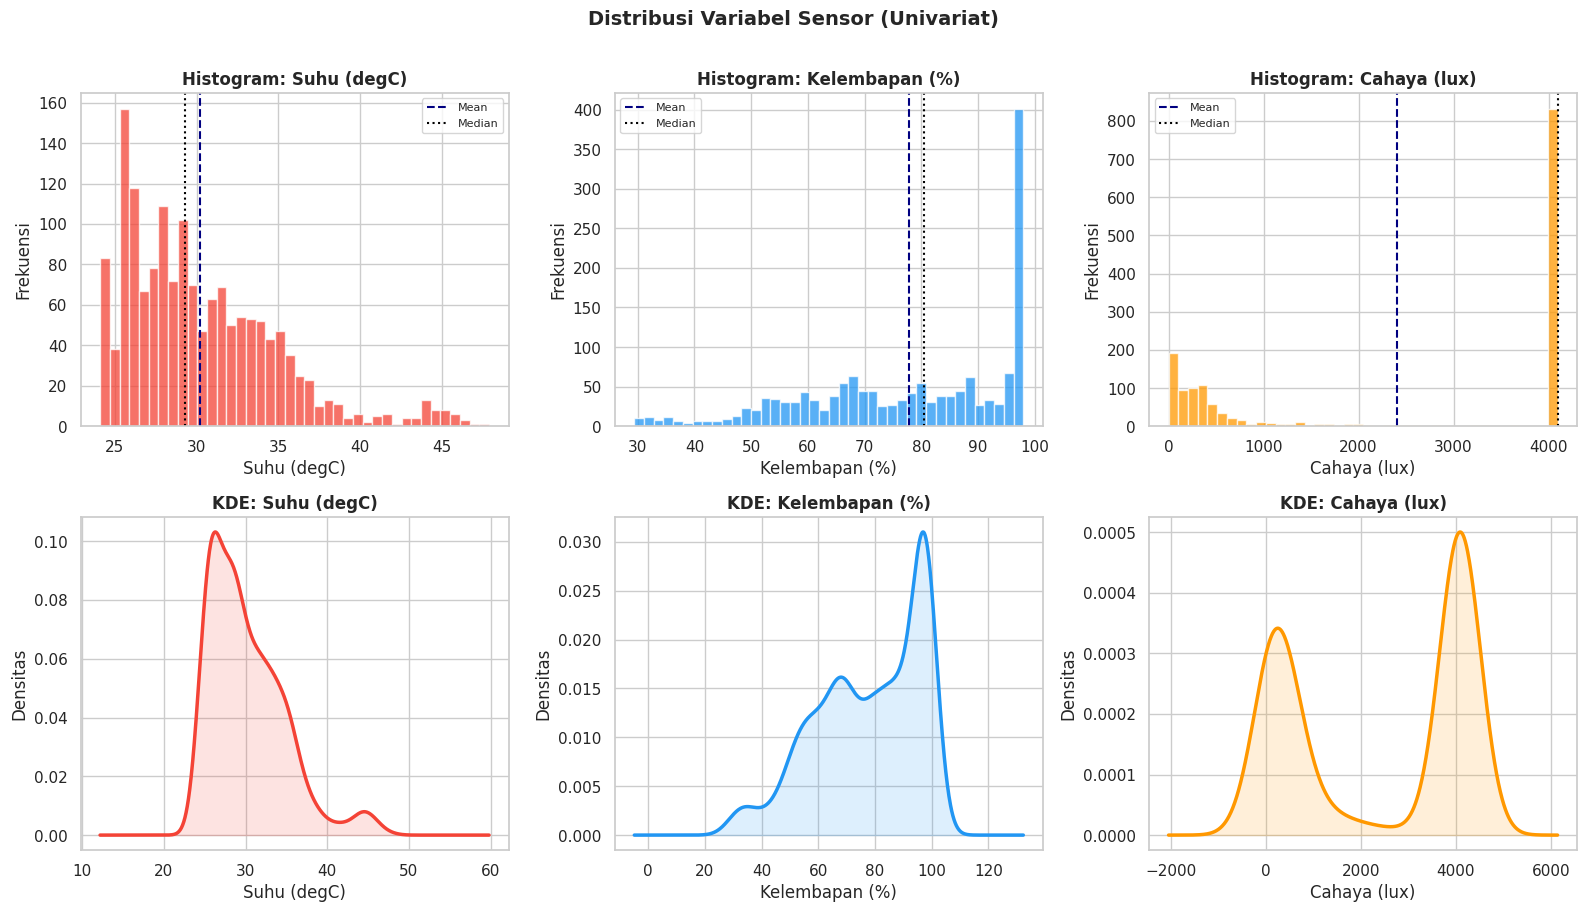


Insight Distribusi:
  Suhu: skewness=1.14 — ekor kanan (ada nilai panas ekstrem siang hari)
  Kelembapan: skewness=-0.58 — ekor kiri (banyak nilai mendekati jenuh 98%)
  Cahaya: 822 data (52.7%) nilai 4095 = sensor SATURASI (lampu/malam)


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
colors_u = ['#F44336', '#2196F3', '#FF9800']
labels_u = ['Suhu (degC)', 'Kelembapan (%)', 'Cahaya (lux)']

for i, (col, color, label) in enumerate(zip(cols_sensor, colors_u, labels_u)):
    ax0 = axes[0, i]
    ax0.hist(df_feat[col].dropna(), bins=40, color=color, alpha=0.75, edgecolor='white')
    ax0.axvline(df_feat[col].mean(),   color='navy',  linestyle='--', lw=1.5, label='Mean')
    ax0.axvline(df_feat[col].median(), color='black', linestyle=':',  lw=1.5, label='Median')
    ax0.set_title(f'Histogram: {label}', fontweight='bold')
    ax0.set_xlabel(label); ax0.set_ylabel('Frekuensi')
    ax0.legend(fontsize=8)

    ax1 = axes[1, i]
    df_feat[col].dropna().plot(kind='kde', ax=ax1, color=color, linewidth=2.5)
    ax1.fill_between(ax1.lines[0].get_xdata(), ax1.lines[0].get_ydata(), alpha=0.15, color=color)
    ax1.set_title(f'KDE: {label}', fontweight='bold')
    ax1.set_xlabel(label); ax1.set_ylabel('Densitas')

plt.suptitle('Distribusi Variabel Sensor (Univariat)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

skew_s = df_feat['suhu'].skew()
skew_k = df_feat['kelembapan'].skew()
n_sat2 = (df_feat['cahaya']==4095).sum()
print(f'\nInsight Distribusi:')
print(f'  Suhu: skewness={skew_s:.2f} — ekor kanan (ada nilai panas ekstrem siang hari)')
print(f'  Kelembapan: skewness={skew_k:.2f} — ekor kiri (banyak nilai mendekati jenuh 98%)')
print(f'  Cahaya: {n_sat2} data ({n_sat2/len(df_feat)*100:.1f}%) nilai 4095 = sensor SATURASI (lampu/malam)')

### 7.3 Time Series Story — "Kisah 5 Hari Sensor Ini"

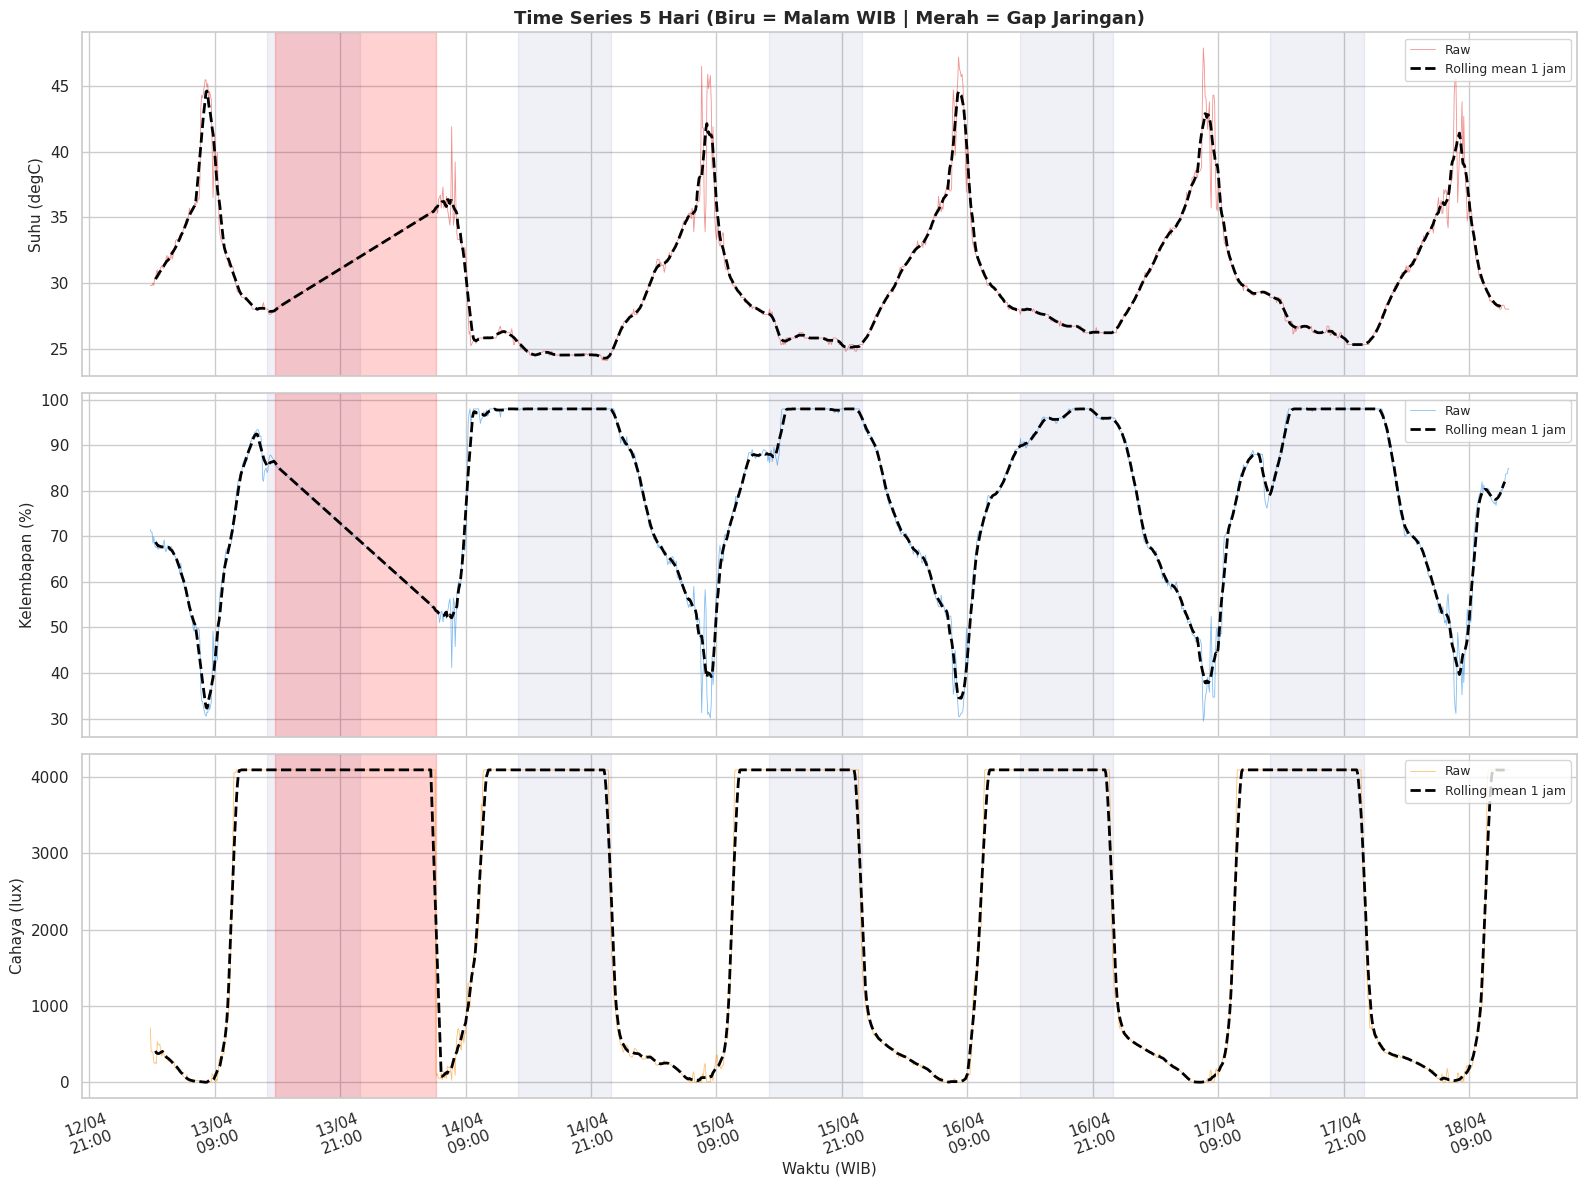


--- STORY: Apa yang terjadi selama 5 hari ini? ---

13 Apr | Sensor mulai merekam pukul 09:52 WIB. Siang pertama sudah mencatat
       | suhu hingga 45.5 degC — hari terpanas dalam dataset. Jaringan
       | mulai fluktuatif sore hari, ada gap kecil-kecil.

GAP    | 13 Apr ~21:33 -> 14 Apr ~13:09 WIB (~15.4 jam tanpa data)
       | Kemungkinan penyebab: router restart, pemadaman listrik,
       | atau hotspot kehabisan kuota di tengah malam.

14 Apr | Sensor kembali online dari siang hari. Suhu lebih moderat
       | (24-42 degC). Malam pertama penuh terekam.

15-18  | Pola harian konsisten: suhu puncak ~14:00-16:00 WIB,
Apr    | kelembapan balik naik setelah sore, cahaya malam saturasi.
       | Hari-hari ini memberikan data paling bersih untuk analisis.


In [12]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
plot_cfg = [
    ('suhu',       '#E53935', 'Suhu (degC)'),
    ('kelembapan', '#1E88E5', 'Kelembapan (%)'),
    ('cahaya',     '#FB8C00', 'Cahaya (lux)'),
]

for ax, (col, color, label) in zip(axes, plot_cfg):
    ax.plot(df_feat.index, df_feat[col], color=color, linewidth=0.6, alpha=0.55, label='Raw')
    rm = df_feat[col].rolling(12, center=True).mean()
    ax.plot(df_feat.index, rm, color='black', linewidth=2, linestyle='--',
            label='Rolling mean 1 jam')

    # Shading malam
    nm = df_feat['is_malam'] == 1
    grps_n = (nm.diff().fillna(nm) != 0).cumsum()
    for gid, grp in df_feat[nm].groupby(grps_n[nm]):
        ax.axvspan(grp.index[0], grp.index[-1], alpha=0.06, color='navy')

    # Shading gap besar
    for _, row in big_gap_times.iterrows():
        ax.axvspan(row['start'], row['end'], alpha=0.18, color='red')

    ax.set_ylabel(label, fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m\n%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))

axes[0].set_title('Time Series 5 Hari (Biru = Malam WIB | Merah = Gap Jaringan)', fontsize=13, fontweight='bold')
axes[-1].set_xlabel('Waktu (WIB)', fontsize=11)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print('\n--- STORY: Apa yang terjadi selama 5 hari ini? ---')
print()
print('13 Apr | Sensor mulai merekam pukul 09:52 WIB. Siang pertama sudah mencatat')
print('       | suhu hingga 45.5 degC — hari terpanas dalam dataset. Jaringan')
print('       | mulai fluktuatif sore hari, ada gap kecil-kecil.')
print()
print('GAP    | 13 Apr ~21:33 -> 14 Apr ~13:09 WIB (~15.4 jam tanpa data)')
print('       | Kemungkinan penyebab: router restart, pemadaman listrik,')
print('       | atau hotspot kehabisan kuota di tengah malam.')
print()
print('14 Apr | Sensor kembali online dari siang hari. Suhu lebih moderat')
print('       | (24-42 degC). Malam pertama penuh terekam.')
print()
print('15-18  | Pola harian konsisten: suhu puncak ~14:00-16:00 WIB,')
print('Apr    | kelembapan balik naik setelah sore, cahaya malam saturasi.')
print('       | Hari-hari ini memberikan data paling bersih untuk analisis.')

### 7.4 Pola Harian (Diurnal Pattern)

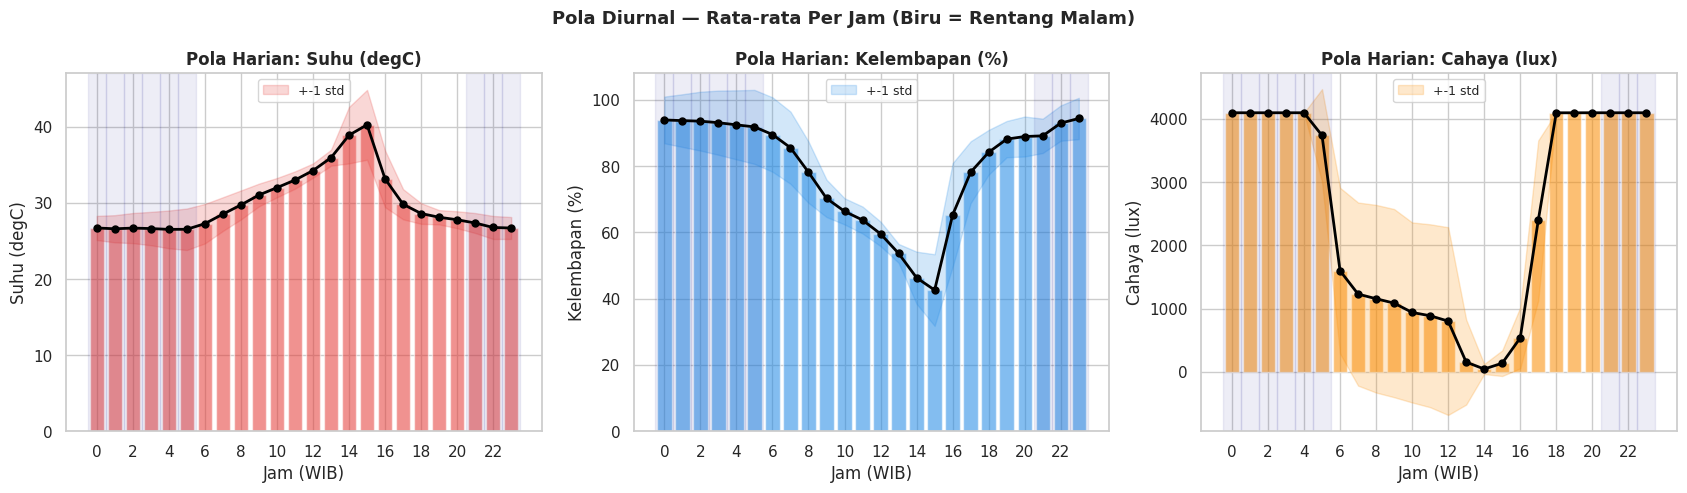


Puncak & Lembah Harian:
  Suhu (degC)         : Puncak jam 15:00 (40.3) | Terendah jam 04:00 (26.5)
  Kelembapan (%)      : Puncak jam 23:00 (94.4) | Terendah jam 15:00 (42.6)
  Cahaya (lux)        : Puncak jam 00:00 (4095.0) | Terendah jam 14:00 (43.5)


In [13]:
hourly     = df_feat.groupby('jam')[cols_sensor].mean()
hourly_std = df_feat.groupby('jam')[cols_sensor].std()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colors_d = ['#E53935', '#1E88E5', '#FB8C00']
labels_d = ['Suhu (degC)', 'Kelembapan (%)', 'Cahaya (lux)']

for ax, (col, color, label) in zip(axes, zip(cols_sensor, colors_d, labels_d)):
    mean_v = hourly[col]
    std_v  = hourly_std[col]
    jam    = hourly.index
    ax.bar(jam, mean_v, color=color, alpha=0.55, edgecolor='white')
    ax.plot(jam, mean_v, color='black', lw=2, marker='o', markersize=5)
    ax.fill_between(jam, mean_v - std_v, mean_v + std_v, alpha=0.2, color=color, label='+-1 std')
    for h in range(24):
        if h >= 21 or h < 6:
            ax.axvspan(h-0.5, h+0.5, alpha=0.07, color='navy')
    ax.set_title(f'Pola Harian: {label}', fontweight='bold')
    ax.set_xlabel('Jam (WIB)'); ax.set_ylabel(label)
    ax.set_xticks(range(0, 24, 2))
    ax.legend(fontsize=9)

plt.suptitle('Pola Diurnal — Rata-rata Per Jam (Biru = Rentang Malam)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nPuncak & Lembah Harian:')
for col, label in zip(cols_sensor, labels_d):
    ph = hourly[col].idxmax()
    th = hourly[col].idxmin()
    print(f'  {label:20s}: Puncak jam {ph:02d}:00 ({hourly[col].max():.1f}) | Terendah jam {th:02d}:00 ({hourly[col].min():.1f})')

### 7.5 Analisis Bivariat (Hubungan Antar Variabel)

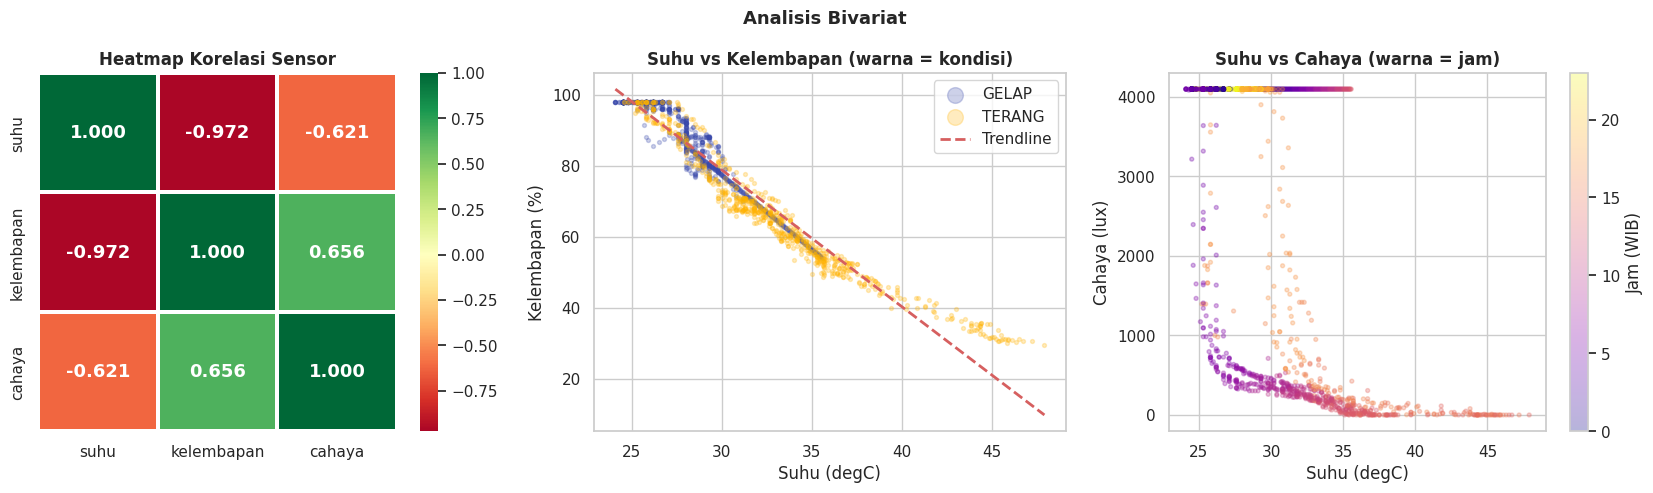


Interpretasi Korelasi:
  Suhu <-> Kelembapan  : r=-0.972 --> Korelasi negatif SANGAT KUAT
                         Semakin panas -> udara makin kering (hukum fisika)
  Suhu <-> Cahaya      : r=-0.621 --> Negatif sedang (PERHATIAN!)
  Kelembapan <-> Cahaya: r=0.656 --> Positif sedang (alasan sama)


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. Heatmap korelasi
corr = df_feat[cols_sensor].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            ax=axes[0], square=True, linewidths=1.5,
            annot_kws={'size': 13, 'weight': 'bold'})
axes[0].set_title('Heatmap Korelasi Sensor', fontweight='bold')

# 2. Scatter suhu vs kelembapan
cmap_k = {'TERANG': '#FFB300', 'GELAP': '#3949AB'}
for kondisi, grp in df_feat.groupby('kondisi'):
    axes[1].scatter(grp['suhu'], grp['kelembapan'],
                    label=kondisi, alpha=0.25, s=8, color=cmap_k.get(kondisi, 'gray'))
coef = np.polyfit(df_feat['suhu'].dropna(), df_feat['kelembapan'].dropna(), 1)
x_line = np.linspace(df_feat['suhu'].min(), df_feat['suhu'].max(), 100)
axes[1].plot(x_line, np.polyval(coef, x_line), 'r--', lw=2, label='Trendline')
axes[1].set_xlabel('Suhu (degC)'); axes[1].set_ylabel('Kelembapan (%)')
axes[1].set_title('Suhu vs Kelembapan (warna = kondisi)', fontweight='bold')
axes[1].legend(markerscale=4)

# 3. Suhu vs cahaya diwarnai per jam
sc = axes[2].scatter(df_feat['suhu'], df_feat['cahaya'],
                     c=df_feat['jam'], cmap='plasma', alpha=0.3, s=8)
plt.colorbar(sc, ax=axes[2], label='Jam (WIB)')
axes[2].set_xlabel('Suhu (degC)'); axes[2].set_ylabel('Cahaya (lux)')
axes[2].set_title('Suhu vs Cahaya (warna = jam)', fontweight='bold')

plt.suptitle('Analisis Bivariat', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nInterpretasi Korelasi:')
print(f'  Suhu <-> Kelembapan  : r={corr.loc["suhu","kelembapan"]:.3f} --> Korelasi negatif SANGAT KUAT')
print('                         Semakin panas -> udara makin kering (hukum fisika)')
print(f'  Suhu <-> Cahaya      : r={corr.loc["suhu","cahaya"]:.3f} --> Negatif sedang (PERHATIAN!)')
print(f'  Kelembapan <-> Cahaya: r={corr.loc["kelembapan","cahaya"]:.3f} --> Positif sedang (alasan sama)')

### 7.6 Multivariat (Heatmap Pola Suhu per Jam x Tanggal)

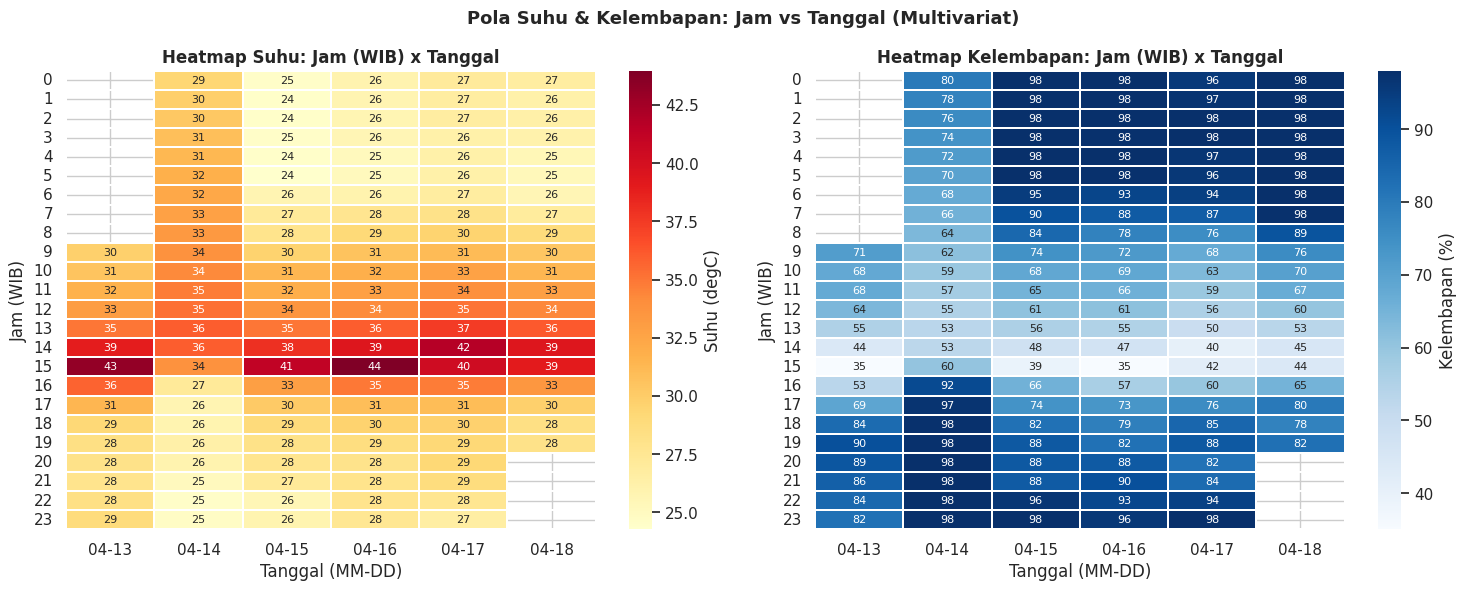


Insight:
  Baris jam 14-15 selalu berwarna merah gelap -> puncak panas konsisten tiap hari
  Baris jam 02-05 selalu biru -> titik terdingin konsisten dini hari
  13 Apr tampak lebih panas rata-rata -> data hanya dari siang hari


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

df_feat['tgl_str'] = df_feat['tanggal'].astype(str).str[5:]  # "MM-DD"

pivot_suhu = df_feat.pivot_table(values='suhu', index='jam', columns='tgl_str', aggfunc='mean')
sns.heatmap(pivot_suhu, cmap='YlOrRd', ax=axes[0], linewidths=0.3, annot=True, fmt='.0f',
            cbar_kws={'label': 'Suhu (degC)'}, annot_kws={'size': 8})
axes[0].set_title('Heatmap Suhu: Jam (WIB) x Tanggal', fontweight='bold')
axes[0].set_xlabel('Tanggal (MM-DD)'); axes[0].set_ylabel('Jam (WIB)')

pivot_kel = df_feat.pivot_table(values='kelembapan', index='jam', columns='tgl_str', aggfunc='mean')
sns.heatmap(pivot_kel, cmap='Blues', ax=axes[1], linewidths=0.3, annot=True, fmt='.0f',
            cbar_kws={'label': 'Kelembapan (%)'}, annot_kws={'size': 8})
axes[1].set_title('Heatmap Kelembapan: Jam (WIB) x Tanggal', fontweight='bold')
axes[1].set_xlabel('Tanggal (MM-DD)'); axes[1].set_ylabel('Jam (WIB)')

plt.suptitle('Pola Suhu & Kelembapan: Jam vs Tanggal (Multivariat)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nInsight:')
print('  Baris jam 14-15 selalu berwarna merah gelap -> puncak panas konsisten tiap hari')
print('  Baris jam 02-05 selalu biru -> titik terdingin konsisten dini hari')
print('  13 Apr tampak lebih panas rata-rata -> data hanya dari siang hari')

### 7.7 Deteksi Cahaya Artifisial ("Kapan Lampu Menyala?")

Sensor berada di teras. Malam hari (21:00–05:59 WIB), jika nilai cahaya > 2000 lux, itu berarti lampu menyala.

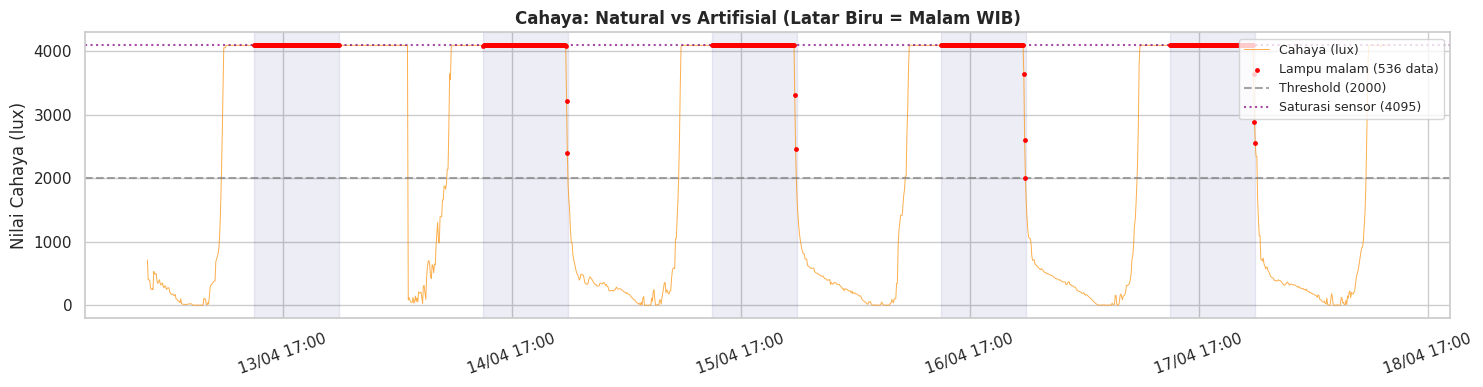

Distribusi Jam Lampu Nyala:
  Jam 00:00  ███████ (60)
  Jam 01:00  ███████ (60)
  Jam 02:00  ███████ (60)
  Jam 03:00  ███████ (60)
  Jam 04:00  ███████ (60)
  Jam 05:00  ███████ (56)
  Jam 21:00  ███████ (60)
  Jam 22:00  ███████ (60)
  Jam 23:00  ███████ (60)


In [18]:
fig, ax = plt.subplots(figsize=(15, 4))

ax.plot(df_feat.index, df_feat['cahaya'], color='#FB8C00', lw=0.7, alpha=0.7, label='Cahaya (lux)')

nm = df_feat['is_malam'] == 1
grps_n2 = (nm.diff().fillna(nm) != 0).cumsum()
for gid, grp in df_feat[nm].groupby(grps_n2[nm]):
    ax.axvspan(grp.index[0], grp.index[-1], alpha=0.07, color='navy')

mask_art = df_feat['cahaya_artifisial'] == 1
ax.scatter(df_feat[mask_art].index, df_feat[mask_art]['cahaya'],
           color='red', s=6, zorder=5, label=f'Lampu malam ({mask_art.sum()} data)')

ax.axhline(y=THRESHOLD_CAHAYA, color='gray',   linestyle='--', alpha=0.7, label=f'Threshold ({THRESHOLD_CAHAYA})')
ax.axhline(y=4095,             color='purple', linestyle=':',  alpha=0.7, label='Saturasi sensor (4095)')

ax.set_title('Cahaya: Natural vs Artifisial (Latar Biru = Malam WIB)', fontweight='bold')
ax.set_ylabel('Nilai Cahaya (lux)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
ax.legend(loc='upper right', fontsize=9)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

art_jam = df_feat[mask_art]['jam'].value_counts().sort_index()
print('Distribusi Jam Lampu Nyala:')
for j, cnt in art_jam.items():
    bar = chr(9608) * (cnt // 8)
    print(f'  Jam {j:02d}:00  {bar} ({cnt})')